In [11]:
# =========================================================
# STAGE 1 — DATASET LOADING
# =========================================================

import os
import numpy as np
from PIL import Image

INPUT_DIR = "/kaggle/input"

cat_files = []
dog_files = []

# Find cat and dog images anywhere inside /kaggle/input
for root, dirs, files in os.walk(INPUT_DIR):
    for fname in files:
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):

            file_path = os.path.join(root, fname)

            if fname.lower().startswith("cat"):
                cat_files.append(file_path)

            elif fname.lower().startswith("dog"):
                dog_files.append(file_path)

print("Cat images found:", len(cat_files))
print("Dog images found:", len(dog_files))

IMG_SIZE = (1080, 1080)
SAMPLE_SIZE = 200

def load_images(files, label, n):
    data = []
    labels = []

    for fname in files[:n]:
        img = Image.open(fname).convert("RGB").resize(IMG_SIZE)

        data.append(np.array(img))
        labels.append(label)

    return data, labels

cat_imgs, cat_labels = load_images(
    cat_files,
    "cat",
    SAMPLE_SIZE
)

dog_imgs, dog_labels = load_images(
    dog_files,
    "dog",
    SAMPLE_SIZE
)

images = np.array(cat_imgs + dog_imgs)
true_labels = cat_labels + dog_labels

print("Images shape:", images.shape)

Cat images found: 25000
Dog images found: 25000
Images shape: (400, 1080, 1080, 3)


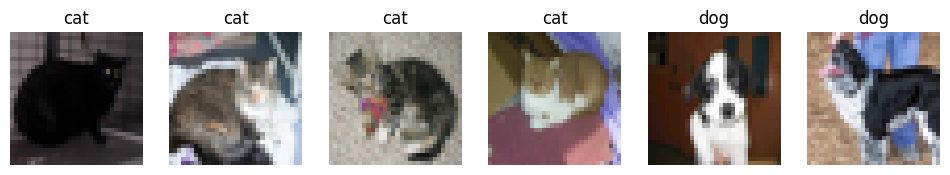

In [3]:
# =========================================================
# STAGE 2 — VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 6,
    figsize=(12, 2)
)

for i in range(6):
    index = i * 65

    axes[i].imshow(images[index])
    axes[i].set_title(true_labels[index])
    axes[i].axis("off")

plt.show()

In [4]:
# =========================================================
# STAGE 3 — PREPROCESSING
# =========================================================

X = images.reshape(
    len(images),
    -1
) / 255.0

print(X.shape)

(400, 3072)


In [8]:
# =========================================================
# STAGE 4 — TRAINING
# =========================================================

X_enhanced = enhanced_images.reshape(
    len(enhanced_images),
    -1
) / 255.0

print("Enhanced X shape:", X_enhanced.shape)


from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_enhanced)

print("K-Means training completed.")

Enhanced X shape: (400, 3072)
K-Means training completed.


In [9]:
# =========================================================
# STAGE 5 — TESTING
# =========================================================

predicted_clusters = kmeans.predict(
    X_enhanced
)

import pandas as pd

print(
    pd.Series(predicted_clusters).value_counts()
)

1    215
0    185
Name: count, dtype: int64


In [10]:
# =========================================================
# STAGE 6 — VALIDATION
# =========================================================

comparison = pd.crosstab(
    predicted_clusters,
    true_labels
)

print(comparison)


col_0  cat  dog
row_0          
0       89   96
1      111  104


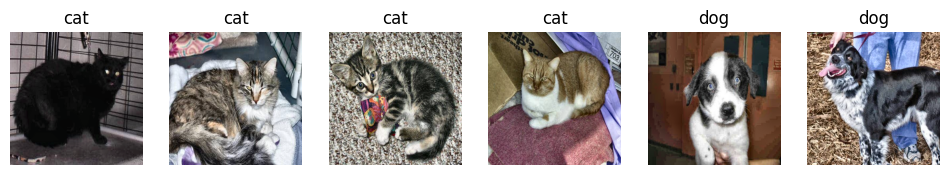

In [12]:
# =========================================================
# EXTRA STAGE — IMAGE ENHANCEMENT
# =========================================================

import cv2

enhanced_images = []

for img in images:

    # Convert RGB to LAB
    lab = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2LAB
    )

    # Split channels
    l, a, b = cv2.split(lab)

    # Create CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    # Enhance contrast
    l = clahe.apply(l)

    # Merge channels
    enhanced_lab = cv2.merge((l, a, b))

    # Convert back to RGB
    enhanced = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    enhanced_images.append(enhanced)


enhanced_images = np.array(enhanced_images)


# Display enhanced images
fig, axes = plt.subplots(
    1, 6,
    figsize=(12, 2)
)

for i in range(6):
    index = i * 65

    axes[i].imshow(enhanced_images[index])
    axes[i].set_title(true_labels[index])
    axes[i].axis("off")

plt.show()